### Routing

Usecase:

- route to a story model or a poem model or a joke model, based on user input.

In [17]:
import os
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model

from pydantic import BaseModel
from typing import Literal
from langgraph.graph import StateGraph, START, END

load_dotenv()

True

In [18]:
#base model

model = init_chat_model(model="groq:llama-3.1-8b-instant")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020C03A287D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020C03A2B470>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [19]:
#defining state schema

class State(BaseModel):
    topic: str
    call_type: Literal['joke', 'story', 'poem', ""]=""
    output: str = ""

In [20]:
#defining class to give it to model for structured output generation

class Router(BaseModel):
    type:Literal['joke', 'poem', 'story']

structured_model = model.with_structured_output(Router)

#sample testing
#structured_model.invoke("say a joke about color")

In [21]:
#defining node for llm call

def generate_joke(state:State):
    "this function generates a joke on given topic"
    response = model.invoke(state.topic)
    return {"output": response.content}

def generate_poem(state:State):
    "this function narrates a poem on given topic"
    response = model.invoke(state.topic)
    return {"output": response.content}

def generate_story(state:State):
    "this function generates a story on given topic"
    response = model.invoke(state.topic)
    return {"output": response.content}

#router funtion

def routing_call(state:State):
    response = structured_model.invoke(state.topic)
    return {"call_type": response.type}

def decision(state:State):
    if state.call_type == "joke":
        return "generate_joke"
    elif state.call_type == "poem":
        return "generate_poem"
    else:
        return "generate_story"


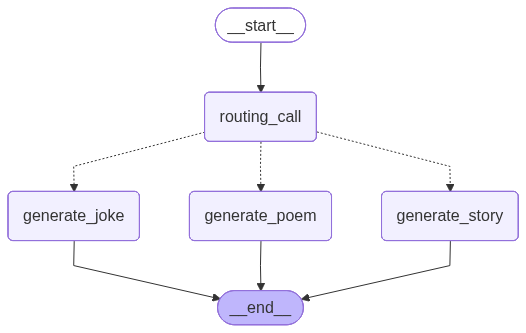

In [22]:
#defining nodes and edges for graph workflow

graph_builder = StateGraph(State)

graph_builder.add_node("generate_poem", generate_poem)
graph_builder.add_node("generate_story", generate_story)
graph_builder.add_node("generate_joke", generate_joke)
graph_builder.add_node("routing_call", routing_call)

graph_builder.add_edge(START, "routing_call")
graph_builder.add_conditional_edges("routing_call", decision, {
    "generate_joke":"generate_joke",
    "generate_poem":"generate_poem",
    "generate_story":"generate_story"
}  )

graph = graph_builder.compile()
graph


In [24]:
#graph invocation

state= State(topic="narrate a poem about beach")

result = graph.invoke(state)
result


{'topic': 'narrate a poem about beach',
 'call_type': 'poem',
 'output': "On shores of golden sand so bright,\nWhere waves caress the morning light,\nThe ocean's melody, a symphony sweet,\nEchoes through the beach, where hearts skip a beat.\n\nThe salty scent of sea and air,\nDances with the whispers of the shore's lair,\nSeagulls soar above, a majestic sight,\nAs the tide rises, with a gentle might.\n\nThe beach, a haven, where dreams unfold,\nWhere sandcastles rise, and stories are told,\nOf laughter, tears, and memories of old,\nForever etched, in the hearts of those bold.\n\nThe sun's warm touch, a gentle caress,\nBrings life to the beach, in all its finesse,\nAs waves crash strong, and foam does play,\nA soothing sound, that chases the night away.\n\nIn this haven, where the world slows down,\nThe beach whispers secrets, to those who listen around,\nOf the tides, the wind, and the waves' gentle song,\nA symphony that echoes, all day long.\n\nSo let us bask, in the beach's warm lig